In [35]:
import pandas as pd
import requests

import os

from dotenv import load_dotenv

from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import matplotlib.pyplot as plt
import seaborn as sns

import joblib

In [21]:
load_dotenv()
URL_BACKEND_PLAYERS = os.getenv('URL_BACKEND_PLAYERS')

In [22]:
def get_players():
    try:
        response = requests.get(URL_BACKEND_PLAYERS)
        if response.status_code == 200:
            return response.json()
        else:
            print(f'Error al obtener los jugadores: {response.status_code} - {response.text}')
            return None
    except Exception as e:
        print(f'Error con la conexión a la API de jugadores: {e}')
        return None

In [23]:
df = pd.DataFrame(get_players())
if df is not None:
    print('Datos cargados exitosamente')
else:
    print('No se puedo cargar los datos')

Datos cargados exitosamente


In [24]:
df.drop(columns='name')

,id,last_season,age,club_name,league_id,position,country_of_birth,height_in_cm,market_value_in_eur,club_id
0,7161,2025,33,Bayer 04 Leverkusen Fußball,L1,Midfield,Germany,176.0,2000000,15
1,12907,2023,31,Unione Sportiva Sassuolo Calcio,IT1,Goalkeeper,Italy,184.0,1500000,6574
2,16306,2025,34,Manchester United Football Club,GB1,Midfield,Brazil,185.0,8000000,985
3,22686,2012,32,Palermo FC,IT1,Attack,Angola,185.0,1500000,458
4,30263,2018,32,Juventus Football Club,IT1,Attack,Italy,182.0,50000,506
...,...,...,...,...,...,...,...,...,...,...
6694,1380977,2025,17,RasenBallsport Leipzig,L1,Attack,France,190.0,0,23826
6695,1384902,2024,20,Rayo Vallecano de Madrid S. A. D.,ES1,Defender,Spain,182.89898989899,25000,367
6696,1390649,2025,19,RasenBallsport Leipzig,L1,Attack,Cote d'Ivoire,180.0,45000000,23826
6697,1453066,2025,17,Villarreal Club de Fútbol S.A.D.,ES1,Midfield,Spain,190.0,0,1050


In [25]:
X = df[['position', 'club_name', 'age', 'last_season', 'league_id', 'country_of_birth', 'height_in_cm']]
y = df['market_value_in_eur']

In [26]:
categorical_features = [
    'position',
    'club_name',
    'league_id',
    'country_of_birth'
]

numerical_features = [
    'age',
    'last_season',
    'height_in_cm'
]

In [27]:
preprocessor = ColumnTransformer(
    transformers = [
        (
            'cat',
            OneHotEncoder(handle_unknown='ignore', sparse_output=False),
            categorical_features
        ),
        (
            'num',
            StandardScaler(),
            numerical_features
        )
    ]
)

In [28]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [29]:
pipeline = Pipeline(
    steps = [
        ('preprocessor', preprocessor),
        ('model', LinearRegression(n_jobs=-1))
    ]
)

In [31]:
pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](7,)","['position','club_name','age',...,'league_id','country_of_birth', 'height_in_cm']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,7
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of

In [32]:
predictions = pipeline.predict(X_test)

In [33]:
mae = mean_absolute_error(y_test, predictions) 
rmse = mean_squared_error(y_test, predictions) ** 0.5 
r2 = r2_score(y_test, predictions) 

print(f"MAE : {mae:,.2f} €") 
print(f"RMSE: {rmse:,.2f} €") 
print(f"R² : {r2:.4f}")

MAE : 5,566,261.31 €
RMSE: 10,244,473.82 €
R² : 0.2531


In [34]:
joblib.dump(pipeline, "../models/linear_regression_model.pkl")

['../models/linear_regression_model.pkl']

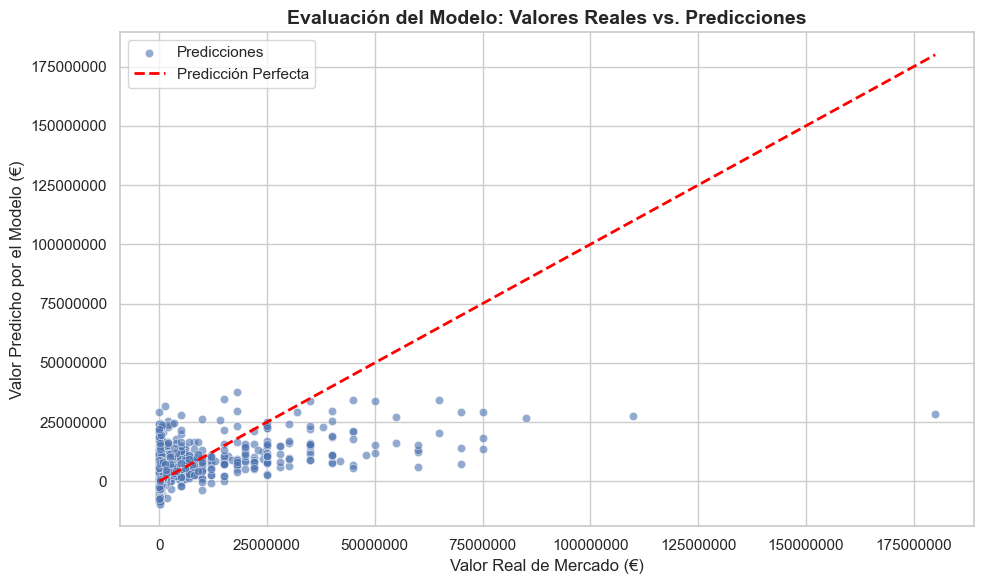

In [37]:
# Configuración del estilo del gráfico
plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")

# 1. Gráfico de dispersión: Valores Reales vs Predicciones
sns.scatterplot(x=y_test, y=predictions, alpha=0.6, color='b', label='Predicciones')

# 2. Línea de referencia ideal (Donde Realidad = Predicción)
# Si el modelo fuera perfecto (R² = 1.0), todos los puntos estarían sobre esta línea.
limite_max = max(max(y_test), max(predictions))
plt.plot([0, limite_max], [0, limite_max], color='red', linestyle='--', linewidth=2, label='Predicción Perfecta')

# Personalización de etiquetas y títulos (asumiendo que y son Euros)
plt.title('Evaluación del Modelo: Valores Reales vs. Predicciones', fontsize=14, fontweight='bold')
plt.xlabel('Valor Real de Mercado (€)', fontsize=12)
plt.ylabel('Valor Predicho por el Modelo (€)', fontsize=12)
plt.legend(loc='upper left')

# Ajustar formato de los ejes para que muestre millones de forma limpia si los números son muy grandes
plt.ticklabel_format(style='plain', axis='both') 

# Mostrar el gráfico
plt.tight_layout()
plt.show()